In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('../dataset/majorproject_df.csv')

In [3]:
df = df.drop([
    'solar_gen_MW',
    'wind_gen_MW',
    'total_gen_MW',
    'installed_solar_MW',
    'installed_wind_MW',
    'panel_area_m2',
    'num_panels',
    'load_MW'
], axis=1)

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True, errors='coerce')


df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df.head()

,datetime,temp_C,humidity_%,wind_speed_m_s,solar_irradiance_W_m2,precip_mm,weather,year,modified_load_MW,month,day,hour
0,2019-01-01 00:00:00,26.33,78.3,5.80,0.0,0.0,Cloudy,2019.0,708.211410,1.0,1.0,0.0
1,2019-01-01 01:00:00,28.42,74.6,3.21,0.0,0.0,Cloudy,2019.0,723.552947,1.0,1.0,1.0
2,2019-01-01 02:00:00,26.14,84.8,4.82,0.0,0.0,Cloudy,2019.0,687.116449,1.0,1.0,2.0
3,2019-01-01 03:00:00,22.16,86.6,3.58,0.0,0.0,Cloudy,2019.0,699.304699,1.0,1.0,3.0
4,2019-01-01 04:00:00,22.26,74.0,3.04,0.0,0.0,Cloudy,2019.0,708.276538,1.0,1.0,4.0


In [5]:
df = df.drop(['datetime'], axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 52608 non-null  float64
 1   humidity_%             52608 non-null  float64
 2   wind_speed_m_s         52608 non-null  float64
 3   solar_irradiance_W_m2  52608 non-null  float64
 4   precip_mm              52608 non-null  float64
 5   weather                52608 non-null  object 
 6   year                   20736 non-null  float64
 7   modified_load_MW       52608 non-null  float64
 8   month                  20736 non-null  float64
 9   day                    20736 non-null  float64
 10  hour                   20736 non-null  float64
dtypes: float64(10), object(1)
memory usage: 4.4+ MB


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
weather_encoded = encoder.fit_transform(df[['weather']])

weather_df = pd.DataFrame(weather_encoded, columns=encoder.get_feature_names_out(['weather']))

df = pd.concat([df.drop(columns=['weather']), weather_df], axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 52608 non-null  float64
 1   humidity_%             52608 non-null  float64
 2   wind_speed_m_s         52608 non-null  float64
 3   solar_irradiance_W_m2  52608 non-null  float64
 4   precip_mm              52608 non-null  float64
 5   year                   20736 non-null  float64
 6   modified_load_MW       52608 non-null  float64
 7   month                  20736 non-null  float64
 8   day                    20736 non-null  float64
 9   hour                   20736 non-null  float64
 10  weather_Cloudy         52608 non-null  float64
 11  weather_Rainy          52608 non-null  float64
 12  weather_Sunny          52608 non-null  float64
dtypes: float64(13)
memory usage: 5.2 MB


In [9]:
import pickle

with open("../models-encoders/load-ohe.pickle", "wb") as file:
    pickle.dump(encoder, file)

In [10]:
# df.corr()[''].abs().sort_values(ascending=False)

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['modified_load_MW'])
y = df['modified_load_MW']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39456, 12)
X_test: (13152, 12)
y_train: (39456,)
y_test: (13152,)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import pickle

with open("../models-encoders/load-encoder.pickle", "wb") as file:
    pickle.dump(scaler, file)

In [14]:
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import pandas as pd
# import numpy as np

# # Define models and hyperparameter grids
# model_params = {
#     "Decision Tree": {
#         'model': DecisionTreeRegressor(),
#         'params': {
#             'max_depth': [3, 5, 10, 100, 1000, None],
#             'min_samples_split': [2, 5, 10],
#             'min_samples_leaf': [1, 2, 4]
#         },
#         'use_scaled': False
#     },
#     "Random Forest": {
#     'model': RandomForestRegressor(random_state=42),
#     'params': {
#         'n_estimators': [100, 200, 500],
#         'max_depth': [None, 10, 20, 30],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4]
#     },
#     'use_scaled': False
# }
#     # Uncomment SVR if you want to try scaled data
#     # "SVR": {
#     #     'model': SVR(),
#     #     'params': {
#     #         'C': [0.1, 1, 10],
#     #         'kernel': ['linear', 'rbf'],
#     #         'epsilon': [0.01, 0.1, 0.5]
#     #     },
#     #     'use_scaled': True
#     # }
# }

# results = []

# # Loop through each model
# for name, mp in model_params.items():
#     print(f"Training {name}...")

#     X_tr = X_train_scaled if mp['use_scaled'] else X_train
#     X_te = X_test_scaled if mp['use_scaled'] else X_test

#     # Grid search
#     grid = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='r2', n_jobs=-1)
#     grid.fit(X_tr, y_train)

#     # Predictions
#     y_pred = grid.predict(X_te)

#     # Metrics
#     r2 = r2_score(y_test, y_pred)
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#     results.append({
#         'Model': name,
#         'Best Params': grid.best_params_,
#         'R2 Score': r2,
#         'MAE': mae,
#         'RMSE': rmse
#     })

# # Convert results to DataFrame and sort by R2
# results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
# print(results_df)


In [15]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [16]:
best_params = {
    'max_depth': 500,
    'min_samples_leaf': 5,
    'min_samples_split': 4,
    'n_estimators': 200
}
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    min_samples_split=best_params['min_samples_split'],
    n_estimators=best_params.get('n_estimators', 100),
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=500, min_samples_leaf=5, min_samples_split=4,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
import pickle

with open("../models-encoders/load-model.pickle", "wb") as file:
    pickle.dump(final_model, file)

XGBoost Test R2: 0.471778
MAE: 134.322858
RMSE: 188.841241


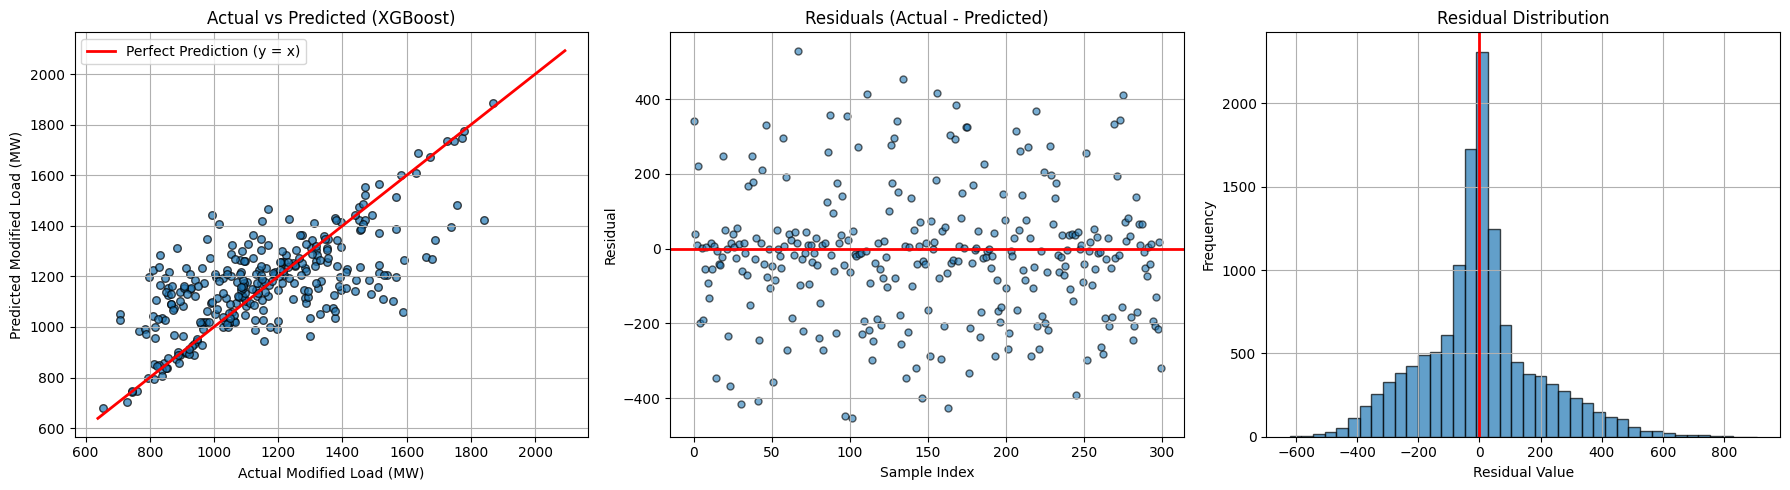

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------
# ✅ XGBoost Predictions
# -------------------------------------------
y_pred = final_model.predict(X_test_scaled)

# -------------------------------------------
# ✅ Metrics
# -------------------------------------------
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"XGBoost Test R2: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

# -------------------------------------------
# ✅ Residuals
# -------------------------------------------
residuals = y_test - y_pred

# -------------------------------------------
# ✅ Create figure with 3 subplots
# -------------------------------------------
plt.figure(figsize=(18, 5))

# ---------------------------------------------------
# 1️⃣ Actual vs Predicted (Zoomed-in for clarity)
# ---------------------------------------------------
plt.subplot(1, 3, 1)
plt.scatter(y_test[:300], y_pred[:300], alpha=0.7, edgecolor='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', lw=2, label='Perfect Prediction (y = x)')
plt.title("Actual vs Predicted (XGBoost)")
plt.xlabel("Actual Modified Load (MW)")
plt.ylabel("Predicted Modified Load (MW)")
plt.legend()
plt.grid(True)

# ---------------------------------------------------
# 2️⃣ Residual Plot
# ---------------------------------------------------
plt.subplot(1, 3, 2)
plt.scatter(range(len(residuals[:300])), residuals[:300],
            alpha=0.6, edgecolor='k', s=25)
plt.axhline(0, color='red', lw=2)
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("Residual")
plt.grid(True)

# ---------------------------------------------------
# 3️⃣ Residual Distribution
# ---------------------------------------------------
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', lw=2)
plt.title("Residual Distribution")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid(True)

# -------------------------------------------
# Final adjustments
# -------------------------------------------
plt.tight_layout()
plt.show()


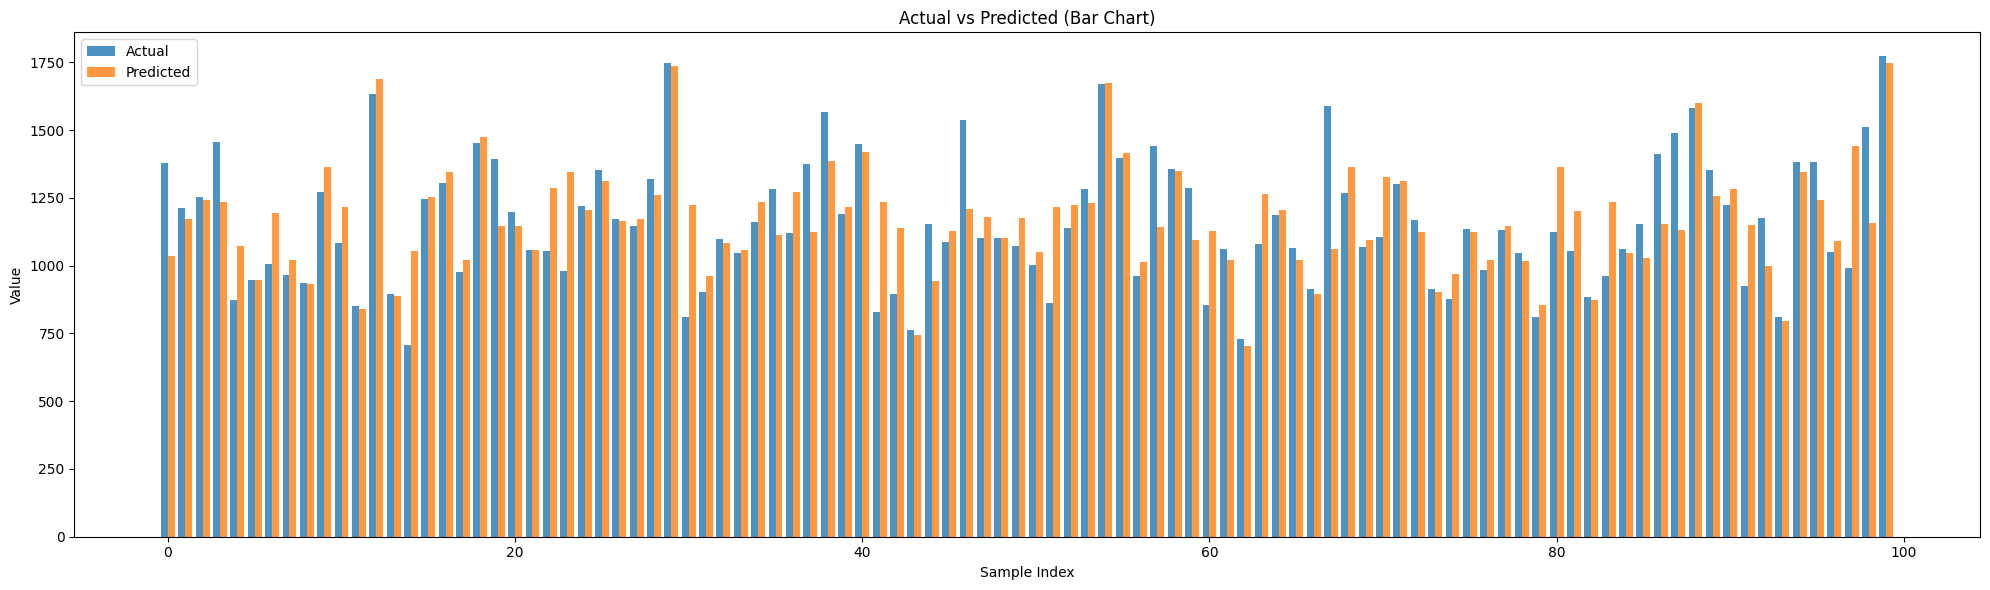

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# y_test and y_pred must already be defined from your model
# Example:
# y_pred = final_model.predict(X_test_scaled)

# Number of samples to show in bar chart (adjustable)
N = 100
indices = np.arange(N)

actual = y_test[:N]
predicted = y_pred[:N]

plt.figure(figsize=(20, 6))

plt.bar(indices - 0.2, actual, width=0.4, label="Actual", alpha=0.8)
plt.bar(indices + 0.2, predicted, width=0.4, label="Predicted", alpha=0.8)

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Actual vs Predicted (Bar Chart)")
plt.legend()
plt.tight_layout()
plt.show()

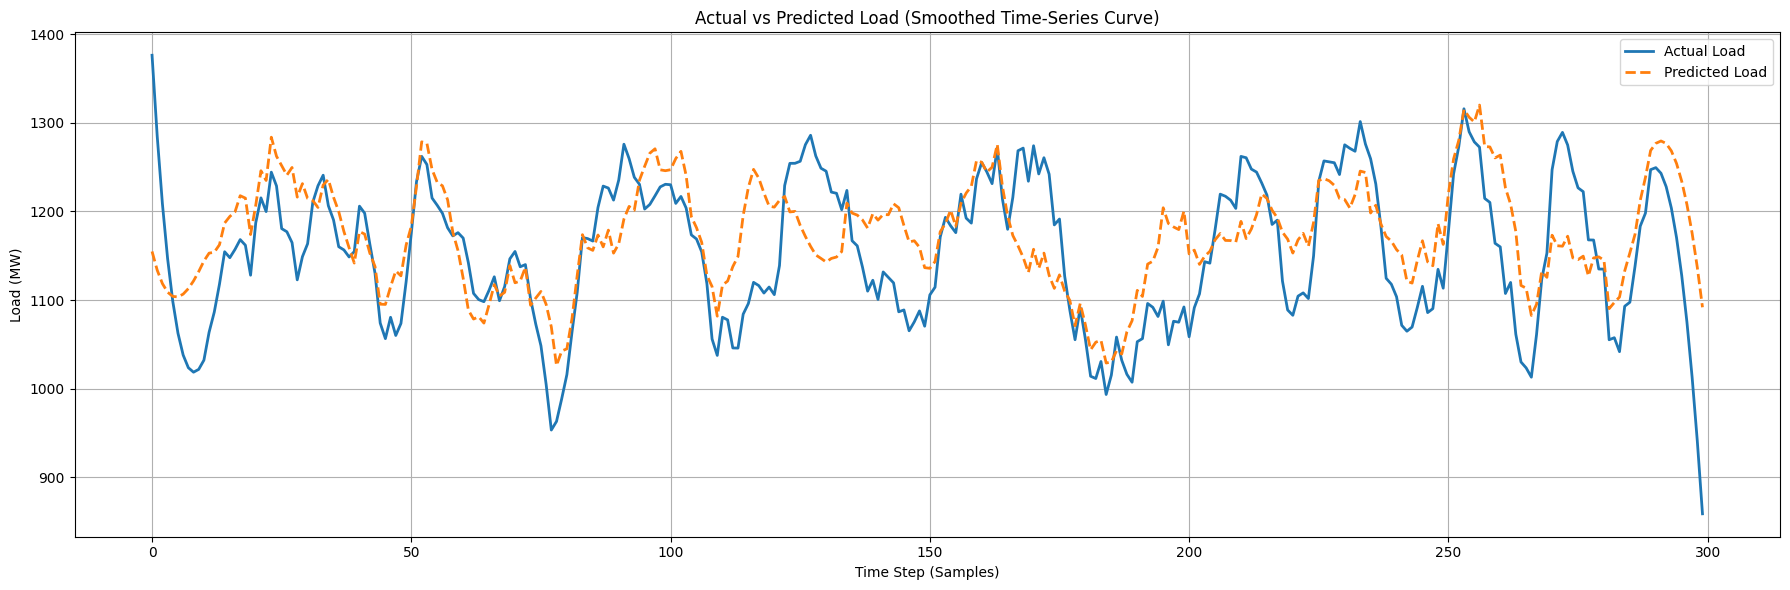

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# ------------------------------
# Use first N points
# ------------------------------
N = 300
actual = np.array(y_test[:N])
predicted = np.array(y_pred[:N])

# ------------------------------
# Smooth curves for "polynomial-like" profile
# ------------------------------
actual_smooth = savgol_filter(actual, window_length=21, polyorder=3)
pred_smooth = savgol_filter(predicted, window_length=21, polyorder=3)

# ------------------------------
# Time axis (just sample indices)
# ------------------------------
time = np.arange(N)

plt.figure(figsize=(18, 6))

plt.plot(time, actual_smooth, label='Actual Load', linewidth=2)
plt.plot(time, pred_smooth, label='Predicted Load', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Load (Smoothed Time-Series Curve)")
plt.xlabel("Time Step (Samples)")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
